# Python Data Analysis Assignment

**Student Name:** Udhay Kiran  
**Program:** Postgraduate Program in Business & Data Analytics  

This notebook solves the Python Data Analysis Assignment using three files:

1. `users_data.csv`
2. `cards_data.csv`
3. `transactions_data.csv`

The solution covers data preprocessing, data hygiene, visualizations, insights, and recommendations.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set(style='whitegrid')

## Load the Dataset

In [3]:
# Keep the CSV files in the same folder as this notebook
users = pd.read_csv('users_data.csv')
cards = pd.read_csv('cards_data.csv')
transactions = pd.read_csv('transactions_data.csv')

print('Users shape:', users.shape)
print('Cards shape:', cards.shape)
print('Transactions shape:', transactions.shape)

display(users.head())
display(cards.head())
display(transactions.head())

Users shape: (25, 14)
Cards shape: (75, 13)
Transactions shape: (50000, 12)


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475509,2010-01-01 04:45:00,1718,4706,$46.21,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN
1,7475582,2010-01-01 06:03:00,511,974,$3.33,Swipe Transaction,20519,Phoenix,AZ,85015.0,5942,NaN
2,7475752,2010-01-01 06:52:00,1718,2029,$10.60,Swipe Transaction,20519,Spring Valley,CA,91977.0,5942,NaN
3,7475819,2010-01-01 07:08:00,511,1038,$21.50,Swipe Transaction,79038,Phoenix,AZ,85015.0,7538,NaN
4,7475828,2010-01-01 07:09:00,1094,3755,$80.00,Swipe Transaction,27092,Boyne City,MI,49712.0,4829,NaN


# Task A: Data Pre-Processing

In [4]:
# Check datatypes
print('Users Data Types')
print(users.dtypes)

print('\nCards Data Types')
print(cards.dtypes)

print('\nTransactions Data Types')
print(transactions.dtypes)

Users Data Types
id                     int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income     object
yearly_income         object
total_debt            object
credit_score           int64
num_credit_cards       int64
dtype: object

Cards Data Types
id                        int64
client_id                 int64
card_brand               object
card_type                object
card_number               int64
expires                  object
cvv                       int64
has_chip                 object
num_cards_issued          int64
credit_limit             object
acct_open_date           object
year_pin_last_changed     int64
card_on_dark_web         object
dtype: object

Transactions Data Types
id                  int64
date               object
client_id           int64
card_id     

## 1 & 2. Convert Numeric Columns and Clean Currency Values

In [5]:
def clean_money_column(series):
    return (series.astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
            .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
            .astype(float))

# Clean users money columns
for col in ['per_capita_income', 'yearly_income', 'total_debt']:
    if col in users.columns:
        users[col] = clean_money_column(users[col])

# Clean cards credit_limit
if 'credit_limit' in cards.columns:
    cards['credit_limit'] = clean_money_column(cards['credit_limit'])

# Clean transaction amount
if 'amount' in transactions.columns:
    transactions['amount'] = clean_money_column(transactions['amount'])

# Convert numeric columns
user_numeric_cols = ['current_age', 'retirement_age', 'birth_year', 'birth_month', 'latitude', 'longitude', 'credit_score', 'num_credit_cards']
card_numeric_cols = ['id', 'client_id', 'num_cards_issued', 'year_pin_last_changed']
transaction_numeric_cols = ['id', 'client_id', 'card_id', 'merchant_id', 'mcc']

for col in user_numeric_cols:
    if col in users.columns:
        users[col] = pd.to_numeric(users[col], errors='coerce')

for col in card_numeric_cols:
    if col in cards.columns:
        cards[col] = pd.to_numeric(cards[col], errors='coerce')

for col in transaction_numeric_cols:
    if col in transactions.columns:
        transactions[col] = pd.to_numeric(transactions[col], errors='coerce')

print('Data type conversion completed.')

Data type conversion completed.


## 3. Check and Handle Duplicate Rows

In [6]:
print('Duplicate rows in users:', users.duplicated().sum())
print('Duplicate rows in cards:', cards.duplicated().sum())
print('Duplicate rows in transactions:', transactions.duplicated().sum())

users = users.drop_duplicates()
cards = cards.drop_duplicates()
transactions = transactions.drop_duplicates()

print('Duplicate rows removed successfully.')

Duplicate rows in users: 0
Duplicate rows in cards: 0
Duplicate rows in transactions: 0
Duplicate rows removed successfully.


## 4. Missing Values: Display, Visualize, and Handle


Missing values in users:
Series([], dtype: int64)

Missing values in cards:
Series([], dtype: int64)

Missing values in transactions:
errors            49145
zip                8358
merchant_state     8008
dtype: int64


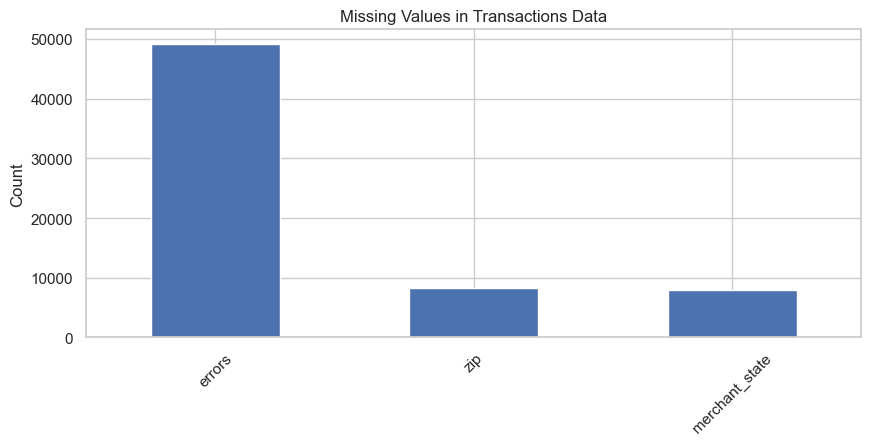

In [7]:
def missing_summary(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f'\nMissing values in {name}:')
    print(missing)
    return missing

missing_users = missing_summary(users, 'users')
missing_cards = missing_summary(cards, 'cards')
missing_transactions = missing_summary(transactions, 'transactions')

for missing, title in [(missing_users, 'Users'), (missing_cards, 'Cards'), (missing_transactions, 'Transactions')]:
    if len(missing) > 0:
        plt.figure(figsize=(10,4))
        missing.plot(kind='bar')
        plt.title(f'Missing Values in {title} Data')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()

In [8]:
# Handle missing values
for df in [users, cards, transactions]:
    numeric_cols = df.select_dtypes(include=np.number).columns
    object_cols = df.select_dtypes(include='object').columns
    
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    
    for col in object_cols:
        df[col] = df[col].fillna('Unknown')

print('Missing values handled using median for numeric columns and Unknown for categorical columns.')

Missing values handled using median for numeric columns and Unknown for categorical columns.


## 5. Convert `use_chip` into Swipe, Chip, or Online

In [9]:
def clean_use_chip(value):
    value = str(value).lower().strip()
    if 'chip' in value:
        return 'chip'
    elif 'swipe' in value:
        return 'swipe'
    elif 'online' in value:
        return 'online'
    else:
        return 'unknown'

transactions['use_chip'] = transactions['use_chip'].apply(clean_use_chip)
transactions['use_chip'].value_counts()

use_chip
swipe     41992
online     8008
Name: count, dtype: int64

## 6, 7 & 8. Clean City Names, State Codes, and ZIP Codes

In [10]:
if 'merchant_city' in transactions.columns:
    transactions['merchant_city'] = transactions['merchant_city'].astype(str).str.strip().str.title()

if 'merchant_state' in transactions.columns:
    transactions['merchant_state'] = transactions['merchant_state'].astype(str).str.strip().str.upper().str[:2]

if 'zip' in transactions.columns:
    transactions['zip'] = transactions['zip'].astype(str).str.replace('.0', '', regex=False).str.zfill(5)

transactions[['merchant_city', 'merchant_state', 'zip']].head()

,merchant_city,merchant_state,zip
0,Online,UN,70510
1,Phoenix,AZ,85015
2,Spring Valley,CA,91977
3,Phoenix,AZ,85015
4,Boyne City,MI,49712


# Task B: Data Analysis

## 1. Customer Card Profile

,card_brand,card_type,card_count,average_credit_limit,total_credit_limit
0,Amex,Credit,1,8800.000000,8800.0
1,Discover,Credit,3,11933.333333,35800.0
2,Mastercard,Credit,4,9850.000000,39400.0
3,Mastercard,Debit,27,21422.703704,578413.0
4,Mastercard,Debit (Prepaid),5,63.200000,316.0
5,Visa,Credit,14,17800.000000,249200.0
6,Visa,Debit,20,33148.150000,662963.0
7,Visa,Debit (Prepaid),1,76.000000,76.0


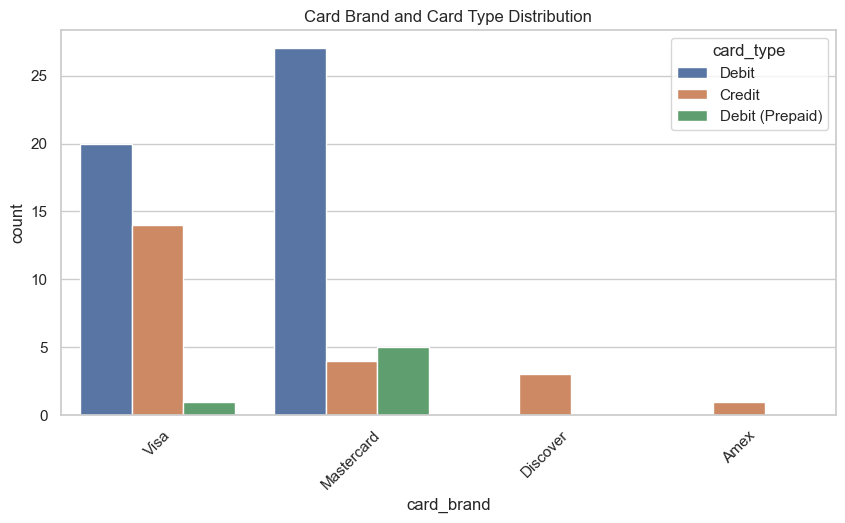

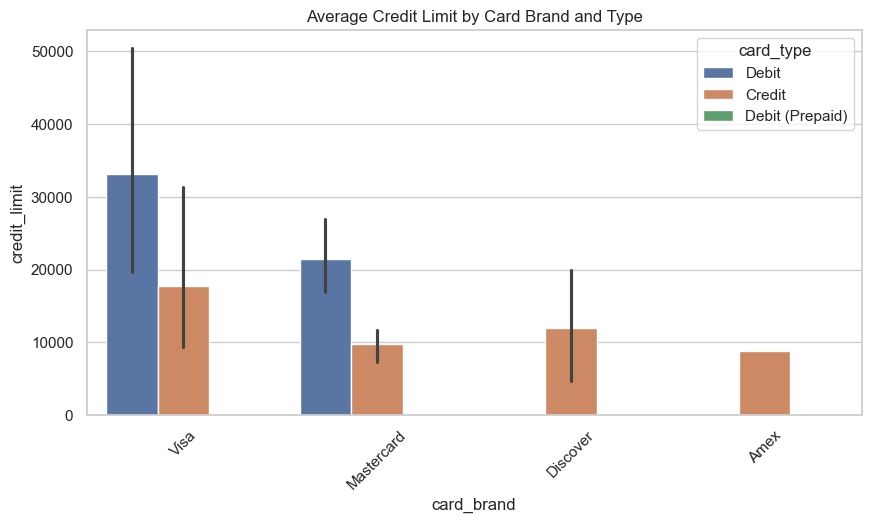

In [11]:
cards_profile = cards.groupby(['card_brand', 'card_type']).agg(
    card_count=('id', 'count'),
    average_credit_limit=('credit_limit', 'mean'),
    total_credit_limit=('credit_limit', 'sum')
).reset_index()

display(cards_profile)

plt.figure(figsize=(10,5))
sns.countplot(data=cards, x='card_brand', hue='card_type')
plt.title('Card Brand and Card Type Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=cards, x='card_brand', y='credit_limit', hue='card_type', estimator=np.mean)
plt.title('Average Credit Limit by Card Brand and Type')
plt.xticks(rotation=45)
plt.show()

**Insights & Recommendations:**  
- Card brands and card types can be compared to identify the most preferred card products.  
- Cards with higher average credit limits can be targeted for premium customers.  
- Low usage card categories can be promoted through reward offers and cashback campaigns.

## 2. Explore Transactions

Data collection start date: 2010-01-01 04:45:00
Data collection end date: 2012-10-29 12:55:00
Client with highest spend: 708 Amount: 326179.31
Highest transaction amount: 6820.2
Lowest transaction amount: -500.0


,use_chip,count,sum,mean
0,online,8008,438554.98,54.764608
1,swipe,41992,2143438.74,51.043978


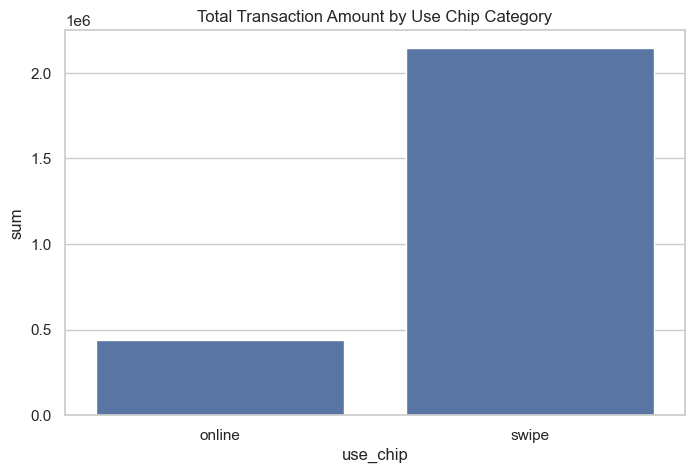

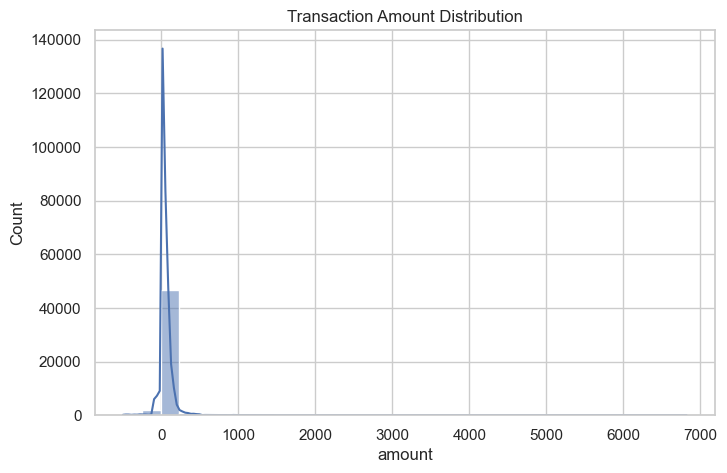

In [12]:
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')

print('Data collection start date:', transactions['date'].min())
print('Data collection end date:', transactions['date'].max())

client_spend = transactions.groupby('client_id')['amount'].sum().sort_values(ascending=False)
print('Client with highest spend:', client_spend.index[0], 'Amount:', client_spend.iloc[0])

print('Highest transaction amount:', transactions['amount'].max())
print('Lowest transaction amount:', transactions['amount'].min())

use_chip_summary = transactions.groupby('use_chip')['amount'].agg(['count', 'sum', 'mean']).reset_index()
display(use_chip_summary)

plt.figure(figsize=(8,5))
sns.barplot(data=use_chip_summary, x='use_chip', y='sum')
plt.title('Total Transaction Amount by Use Chip Category')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(transactions['amount'], bins=30, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

**Insights & Recommendations:**  
- The highest spending customers should be considered for loyalty programs.  
- The preferred transaction mode shows whether customers mostly use chip, swipe, or online transactions.  
- High transaction values should be monitored for risk and fraud detection.

## 3. Customer Spend Profile vs Credit Health

,client_id,total_spend,average_ticket_size,transaction_count,active_months,monthly_frequency,credit_score,yearly_income,total_debt,num_credit_cards
0,68,202013.82,57.098310,3538,34,104.058824,704,41997.0,0.0,3
1,153,70806.08,55.447204,1277,34,37.558824,660,27484.0,16803.0,4
2,511,285794.61,43.646092,6548,34,192.588235,661,35602.0,55369.0,5
3,708,326179.31,132.917404,2454,34,72.176471,722,249925.0,202328.0,4
4,825,259484.68,81.088962,3200,34,94.117647,787,59696.0,127613.0,5


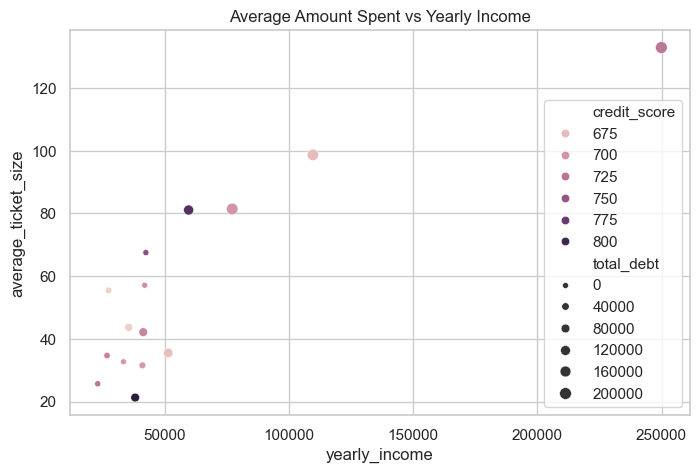

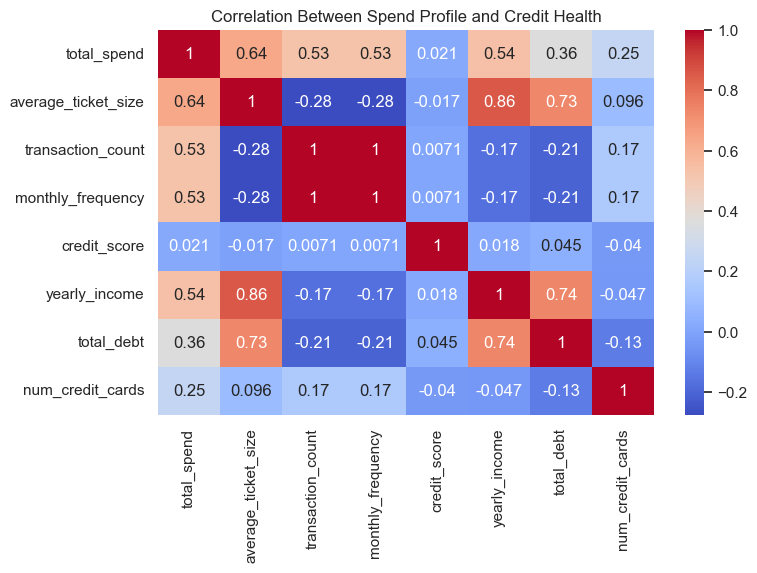

In [13]:
transactions['month'] = transactions['date'].dt.to_period('M')

spend_profile = transactions.groupby('client_id').agg(
    total_spend=('amount', 'sum'),
    average_ticket_size=('amount', 'mean'),
    transaction_count=('id', 'count'),
    active_months=('month', 'nunique')
).reset_index()

spend_profile['monthly_frequency'] = spend_profile['transaction_count'] / spend_profile['active_months'].replace(0, np.nan)

credit_health = users[['id', 'credit_score', 'yearly_income', 'total_debt', 'num_credit_cards']].rename(columns={'id': 'client_id'})
customer_credit_profile = spend_profile.merge(credit_health, on='client_id', how='left')

display(customer_credit_profile.head())

plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_credit_profile, x='yearly_income', y='average_ticket_size', hue='credit_score', size='total_debt')
plt.title('Average Amount Spent vs Yearly Income')
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(customer_credit_profile[['total_spend','average_ticket_size','transaction_count','monthly_frequency','credit_score','yearly_income','total_debt','num_credit_cards']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Spend Profile and Credit Health')
plt.show()

**Insights & Recommendations:**  
- Customers with high income and strong credit scores can be offered premium cards.  
- Customers with high debt and high spending should be monitored carefully.  
- Average ticket size helps identify valuable customers for personalized offers.

## 4. Age Portfolio

,age_band,customer_share_percent
0,60+,28.0
1,25-35,24.0
2,36-45,20.0
3,46-60,16.0
4,Below 25,12.0


/var/folders/bf/rswbvkx54nz7mrlf9zj_bbqh0000gn/T/ipykernel_3401/4284181371.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_credit_limit = user_cards.groupby('age_band')['credit_limit'].mean().reset_index()


,age_band,credit_limit
0,Below 25,35299.333333
1,25-35,13548.000000
2,36-45,13677.285714
3,46-60,15278.705882
4,60+,28256.444444


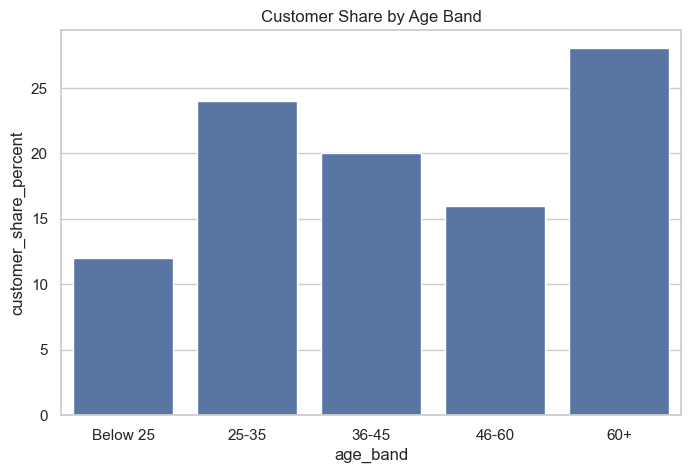

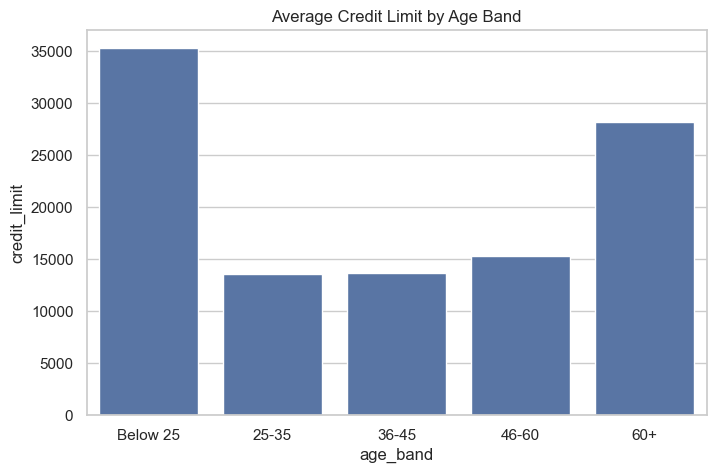

/var/folders/bf/rswbvkx54nz7mrlf9zj_bbqh0000gn/T/ipykernel_3401/4284181371.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chip_age = trans_users.groupby(['age_band','use_chip']).size().reset_index(name='transaction_count')


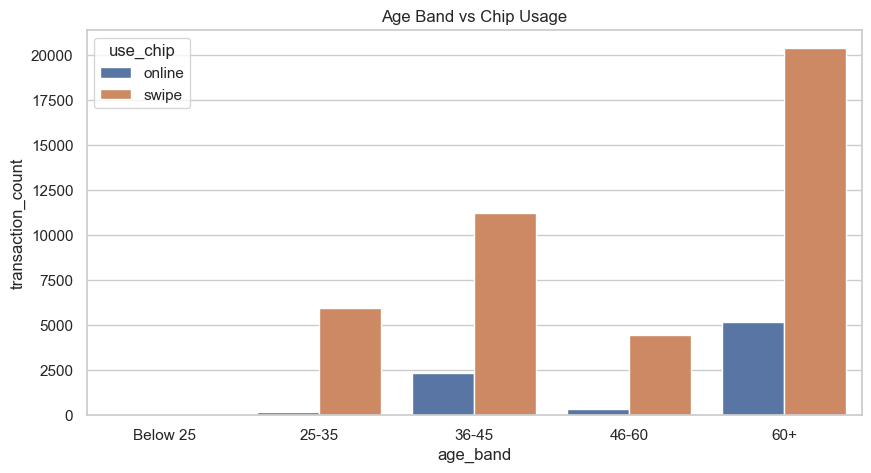

Young customer transaction mode share:
use_chip
swipe     96.810415
online     3.189585
Name: proportion, dtype: float64


In [14]:
users['age_band'] = pd.cut(users['current_age'], bins=[0,25,35,45,60,100], labels=['Below 25','25-35','36-45','46-60','60+'])

user_cards = users[['id','current_age','age_band','yearly_income','credit_score']].rename(columns={'id':'client_id'}).merge(cards, on='client_id', how='left')
age_share = users['age_band'].value_counts(normalize=True).mul(100).reset_index()
age_share.columns = ['age_band', 'customer_share_percent']
display(age_share)

age_credit_limit = user_cards.groupby('age_band')['credit_limit'].mean().reset_index()
display(age_credit_limit)

plt.figure(figsize=(8,5))
sns.barplot(data=age_share, x='age_band', y='customer_share_percent')
plt.title('Customer Share by Age Band')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=age_credit_limit, x='age_band', y='credit_limit')
plt.title('Average Credit Limit by Age Band')
plt.show()

trans_users = transactions.merge(users[['id','age_band','yearly_income','credit_score']], left_on='client_id', right_on='id', how='left')

chip_age = trans_users.groupby(['age_band','use_chip']).size().reset_index(name='transaction_count')
plt.figure(figsize=(10,5))
sns.barplot(data=chip_age, x='age_band', y='transaction_count', hue='use_chip')
plt.title('Age Band vs Chip Usage')
plt.show()

young_online = trans_users[trans_users['age_band'].isin(['Below 25','25-35'])]['use_chip'].value_counts(normalize=True) * 100
print('Young customer transaction mode share:')
print(young_online)

**Insights & Recommendations:**  
- Age bands help identify which customer group dominates the portfolio.  
- If young customers show higher online usage, digital campaigns and app-based offers should be prioritized.  
- Older customers may respond better to secure card benefits and service-based offers.

## 5. Gender Analysis

,gender,amount
0,Female,51.678074
1,Male,51.573033


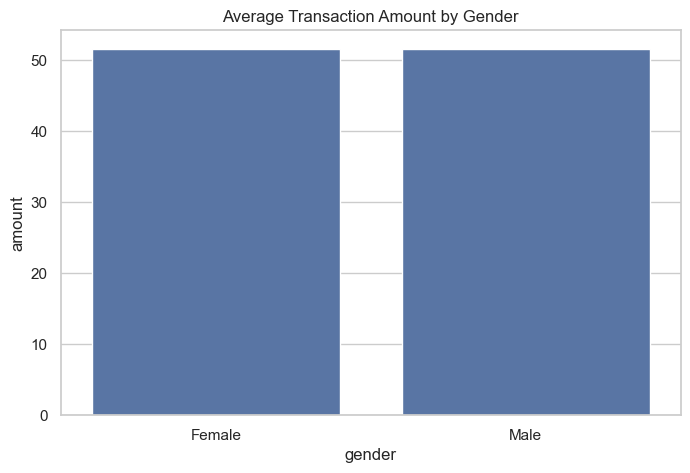

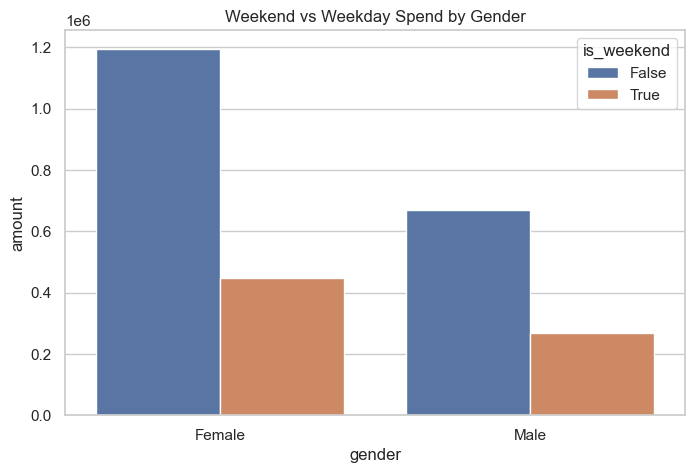

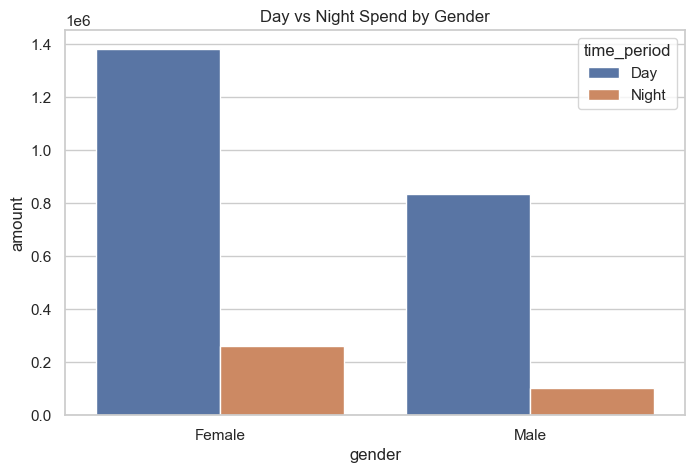

In [15]:
trans_gender = transactions.merge(users[['id','gender']], left_on='client_id', right_on='id', how='left')
trans_gender['hour'] = trans_gender['date'].dt.hour
trans_gender['day_of_week'] = trans_gender['date'].dt.day_name()
trans_gender['is_weekend'] = trans_gender['day_of_week'].isin(['Saturday','Sunday'])
trans_gender['time_period'] = np.where(trans_gender['hour'].between(18,23), 'Night', 'Day')

gender_avg = trans_gender.groupby('gender')['amount'].mean().reset_index()
display(gender_avg)

plt.figure(figsize=(8,5))
sns.barplot(data=gender_avg, x='gender', y='amount')
plt.title('Average Transaction Amount by Gender')
plt.show()

weekend_gender = trans_gender.groupby(['gender','is_weekend'])['amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=weekend_gender, x='gender', y='amount', hue='is_weekend')
plt.title('Weekend vs Weekday Spend by Gender')
plt.show()

time_gender = trans_gender.groupby(['gender','time_period'])['amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=time_gender, x='gender', y='amount', hue='time_period')
plt.title('Day vs Night Spend by Gender')
plt.show()

**Insights & Marketing Campaign Ideas:**  
- Gender-wise average transaction amount helps identify high-value customer groups.  
- Weekend-heavy groups can be targeted with weekend cashback offers.  
- Night-spending customers can be targeted with food delivery, entertainment, and travel offers.  
- Campaigns should be personalized based on transaction timing and spending category.

# Final Conclusion

This analysis cleaned the datasets, handled duplicates and missing values, standardized transaction fields, and generated customer-level insights. The main business actions recommended are:

1. Offer premium products to high-income and high-credit-score customers.
2. Monitor high-spend customers with high debt for credit risk.
3. Create online and mobile-first offers for younger customers.
4. Use gender and timing-based spending patterns for personalized marketing campaigns.
5. Promote low-performing card categories with rewards and cashback offers.